# Confounder Selection

Notes on which variables we should adjust for when we estimate the effect of household wealth on probable depression and probable anxiety.

We do not start from a number. We take every candidate covariate on its own (all 21 in the dictionary), ask the same few questions about it, and decide what it is in the causal story: a confounder, a mediator, a collider, or something else. The number of confounders is whatever is left at the end.

What we are working with:

- exposure: household wealth quintile (`Socioeconomic Status`)
- outcomes: probable depression and probable anxiety (PHQ-9 and GAD-7 band 2 or higher)
- effect modifier: `Cardiometabolic Burden`

Each candidate gets a short write-up, its answers to the questions, a verdict, and a small DAG drawn from those answers. The data is only used to show how each variable is coded and how thin its cells are. It never decides a label.

In [1]:
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", None)
plt.rcParams["figure.dpi"] = 100

# flip to True if you want the figures and the summary table written into the repo
SAVE = False

In [2]:
df_depression = pd.read_csv("../resources/depression-anxiety-dataset.csv")
df_anxiety = pd.read_csv("../resources/depression-anxiety-dataset.csv")

# same cutoff as the main analysis: band 2 or higher is a probable case
df_depression["Y"] = (df_depression["Depression"] >= 2).astype(int)
df_anxiety["Y"] = (df_anxiety["Anxiety"] >= 2).astype(int)

print("depression:", df_depression.shape, "| events:", df_depression["Y"].sum())
print("anxiety:   ", df_anxiety.shape, "| events:", df_anxiety["Y"].sum())

depression: (4887, 37) | events: 235
anxiety:    (4887, 37) | events: 221


## 1. The questions and the labels

The same short list for every candidate. Nothing clever, it is the old triangle test with wealth, the outcome and burden at the corners.

1. Does it cause wealth, or sit before wealth and reach it?
2. Can wealth cause it?
3. Does it reach depression or anxiety by a route that does not go through wealth?
4. Can depression or anxiety cause it? Can burden?
5. Does it cause burden?

The answers are yes, no or unclear. Unclear is allowed, but then we say which way we lean and keep the other reading for a sensitivity model.

Two things to keep in mind. First, we are after the total effect of wealth, so anything wealth causes is not a confounder, however much it correlates with both wealth and the outcome. Second, burden is very likely a result of wealth too (food, weight, blood pressure). That matters for the collider question and for how we word the final model, and we come back to it at the end.

The answers decide the label, through the function below. We keep the rules in one place so nobody, including us, can change a label without changing an answer.

In [3]:
# what each label means and what we do with it for the total effect of wealth
# {c} is filled in with the name of the candidate when we draw it
CLASS_INFO = {
    "confounder": dict(
        color=("#cfe8c9", "#2e7d32"), looks="causes wealth, causes the outcome, wealth does not cause it",
        todo="adjust", path="backdoor path: wealth <- {c} -> outcome. Adjusting for it closes the path."),
    "proxy": dict(
        color=("#eef7e8", "#7cb342"), looks="measured, tells us something about a confounder we can not measure",
        todo="adjust, as a stand-in", path="stands in for something unmeasured. Adjusting removes part of that bias, not all."),
    "mediator": dict(
        color=("#f7cfc7", "#c62828"), looks="caused by wealth, causes the outcome",
        todo="leave out of the total effect model", path="causal path: wealth -> {c} -> outcome. Adjusting blocks part of the effect we want."),
    "collider": dict(
        color=("#f7cfc7", "#8b1a1a"), looks="caused by the outcome and by burden or wealth",
        todo="never adjust", path="burden -> {c} <- outcome. Adjusting opens a path that is not causal."),
    "effect of the outcome": dict(
        color=("#f7cfc7", "#8b1a1a"), looks="caused by the outcome, nothing else on our list",
        todo="do not adjust", path="an effect of the outcome. Adjusting for it distorts the wealth estimate."),
    "precision": dict(
        color=("#e3ebf6", "#5c7cad"), looks="causes the outcome, does not touch wealth",
        todo="not needed for bias, harmless", path="reaches the outcome but not wealth. Adjusting removes no bias for wealth."),
    "instrument-like": dict(
        color=("#ececec", "#777777"), looks="causes wealth, does not touch the outcome",
        todo="not needed, can add noise", path="reaches wealth but not the outcome. Adjusting removes nothing."),
    "irrelevant descendant": dict(
        color=("#ffffff", "#aaaaaa"), looks="caused by wealth, no route to the outcome",
        todo="nothing to do", path="caused by wealth, no route to the outcome."),
    "unrelated": dict(
        color=("#ffffff", "#aaaaaa"), looks="no route to wealth or to the outcome",
        todo="nothing to do", path="no route to wealth or to the outcome."),
}


def classify(a):
    """
    answers in, label out. returns (label, other_reading).
    other_reading is only filled in when the call is contested.
    """
    cw, bw, cy = a["causes_wealth"], a["caused_by_wealth"], a["causes_outcome"]

    # anything the outcome causes gets looked at first
    if a["caused_by_outcome"] == "yes":
        if a["caused_by_burden"] == "yes" or bw == "yes":
            return "collider", None
        return "effect of the outcome", None

    # timing is the open question, so we go with the lean and keep the other reading
    if bw == "unclear":
        if cy != "yes":
            return "unrelated", None
        return ("confounder", "mediator") if a["lean"] == "before" else ("mediator", "confounder")

    # wealth causes it
    if bw == "yes":
        return ("mediator" if cy == "yes" else "irrelevant descendant"), None

    # from here on wealth does not cause it
    if cy == "unclear":
        if cw == "yes":
            return ("confounder", "instrument-like") if a["lean"] == "yes" else ("instrument-like", "confounder")
        return "unrelated", None
    if cw == "yes" and cy == "yes":
        return "confounder", None
    if cw == "yes":
        return "instrument-like", None
    if cy == "yes":
        return ("proxy" if a["proxy_for"] else "precision"), None
    return "unrelated", None


pd.DataFrame([{"label": k, "how we recognise it": v["looks"], "what we do (total effect)": v["todo"]}
              for k, v in CLASS_INFO.items() if k != "unrelated"])

,label,how we recognise it,what we do (total effect)
0,confounder,"causes wealth, causes the outcome, wealth does not cause it",adjust
1,proxy,"measured, tells us something about a confounder we can not measure","adjust, as a stand-in"
2,mediator,"caused by wealth, causes the outcome",leave out of the total effect model
3,collider,caused by the outcome and by burden or wealth,never adjust
4,effect of the outcome,"caused by the outcome, nothing else on our list",do not adjust
5,precision,"causes the outcome, does not touch wealth","not needed for bias, harmless"
6,instrument-like,"causes wealth, does not touch the outcome","not needed, can add noise"
7,irrelevant descendant,"caused by wealth, no route to the outcome",nothing to do


## 2. Drawing a candidate

Every candidate gets the same small picture. Wealth, burden and the outcome are fixed in a row (wealth causes burden, burden causes the outcome, wealth also has its own arrow into the outcome, drawn underneath). The candidate sits on top and its arrows follow from the answers. A thick coloured arrow is a route that matters for its label, an amber dotted arrow is something we said was unclear, a purple arrow goes into burden, and a grey dashed node is something we can not measure.

Here are the labels themselves on made-up candidates, so the pictures are familiar when the real ones come.

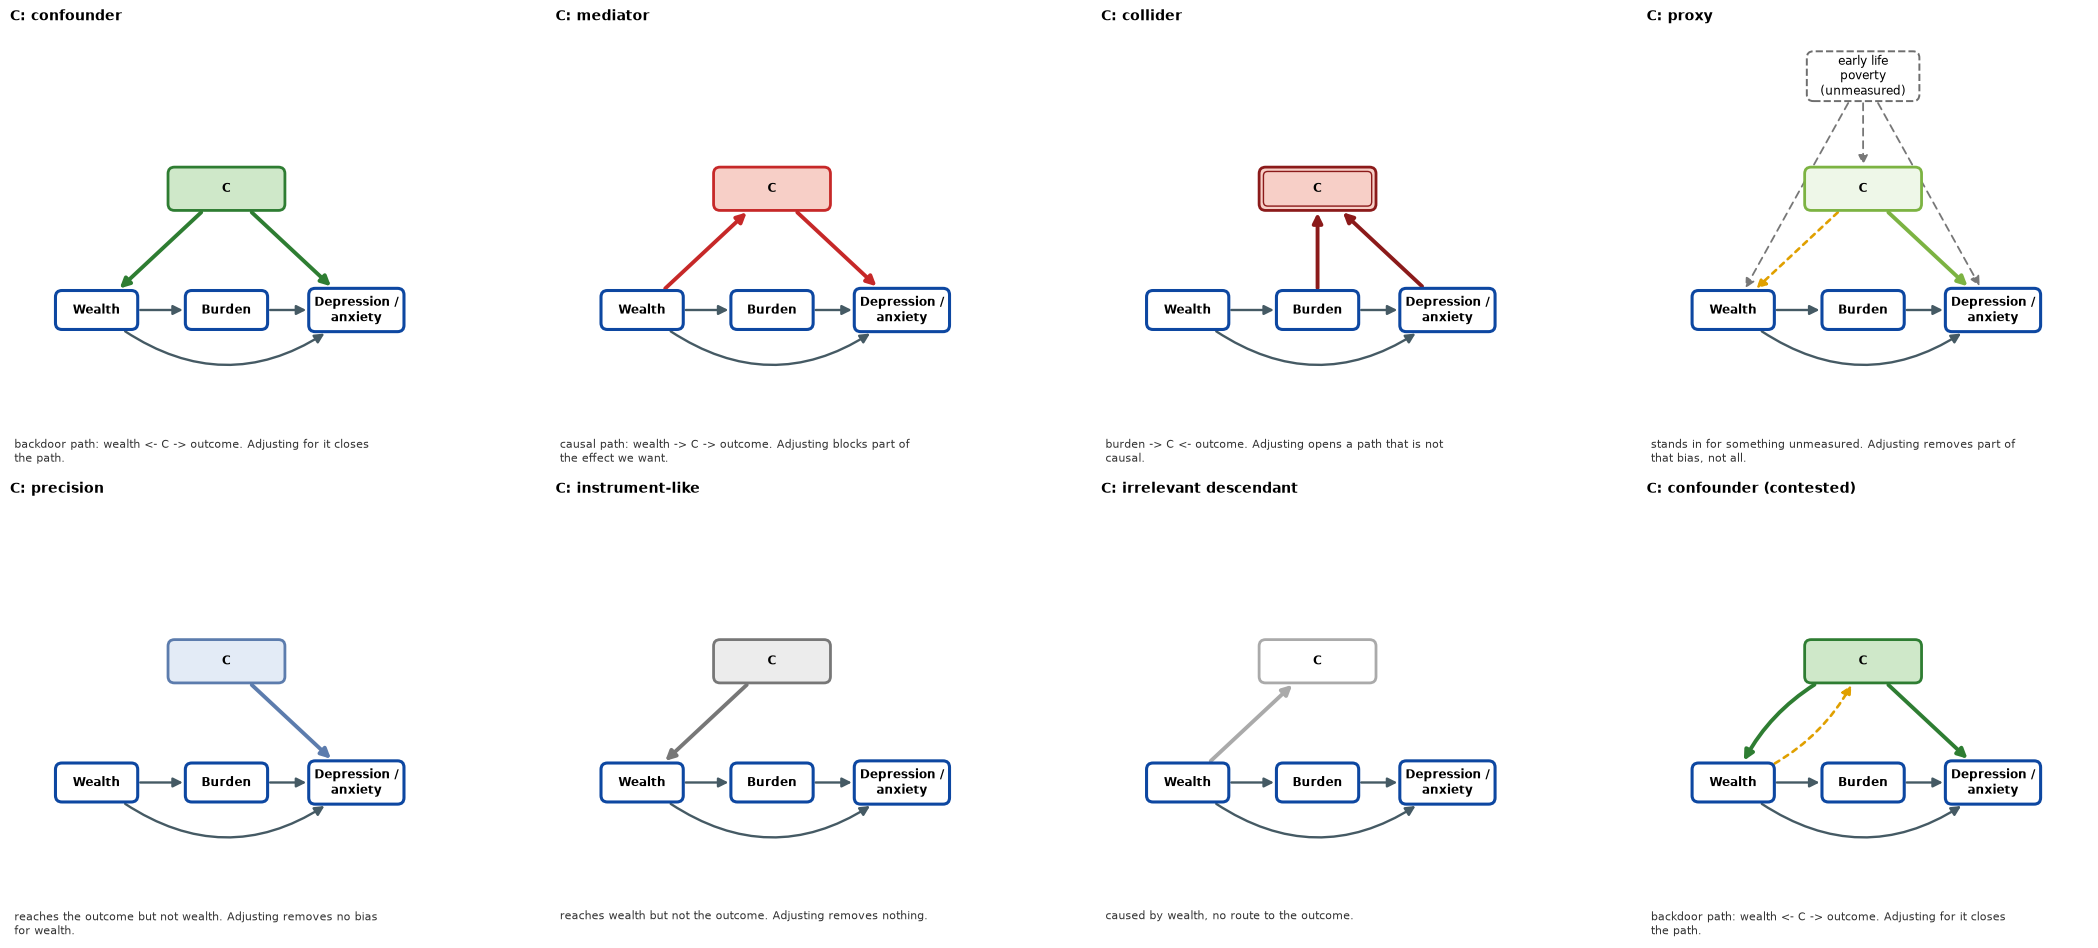

In [4]:
NODE_POS = {"W": (0.0, 0.0), "B": (3.0, 0.0), "Y": (6.0, 0.0), "C": (3.0, 2.8)}
HIDDEN_POS = {"top": (3.0, 5.4), "left": (-0.6, 4.0), "right": (6.6, 4.0)}
NODE_TEXT = {"W": "Wealth", "B": "Burden", "Y": "Depression /\nanxiety"}
NODE_SIZE = {"W": (1.9, 0.9), "B": (1.9, 0.9), "Y": (2.2, 1.0), "C": (2.7, 1.0)}


def candidate_edges(a):
    """the arrows around the candidate that follow from our answers"""
    e = []
    if a["caused_by_wealth"] == "unclear":
        e.append(("C", "W", "hot" if a["lean"] == "before" else "maybe"))
        e.append(("W", "C", "hot" if a["lean"] == "after" else "maybe"))
    else:
        if a["causes_wealth"] == "yes":
            e.append(("C", "W", "hot"))
        elif a["causes_wealth"] == "unclear":
            e.append(("C", "W", "maybe"))
        if a["caused_by_wealth"] == "yes":
            e.append(("W", "C", "hot"))
    if a["causes_outcome"] == "yes":
        e.append(("C", "Y", "hot"))
    elif a["causes_outcome"] == "unclear":
        e.append(("C", "Y", "maybe"))
    if a["caused_by_outcome"] == "yes":
        e.append(("Y", "C", "hot"))
    elif a["caused_by_outcome"] == "unclear":
        e.append(("Y", "C", "maybe"))
    if a["caused_by_burden"] == "yes":
        e.append(("B", "C", "hot"))
    if a["causes_burden"] == "yes":
        e.append(("C", "B", "side"))
    return e


def draw_candidate(ax, name, a, cls, alt=None, hidden=None, title=None, top=None):
    fc, ec = CLASS_INFO[cls]["color"]
    if top is None:
        top = 6.5 if (hidden and hidden[1] == "top") else (5.2 if hidden else 4.3)
    ax.set_xlim(-2.0, 8.2)
    ax.set_ylim(-3.1, top)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    flat = name.replace("\n", " ")
    ax.set_title(title or (flat + ": " + cls + (" (contested)" if alt else "")), loc="left", fontsize=10, fontweight="bold")

    boxes = {}

    def box(key, xy, size, text, face, edge, ls="-", lw=1.5, bold=False):
        (x, y), (w, h) = xy, size
        p = FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0,rounding_size=0.15",
                           fc=face, ec=edge, ls=ls, lw=lw, zorder=3)
        ax.add_patch(p)
        ax.text(x, y, text, ha="center", va="center", fontsize=8.6, fontweight="bold" if bold else "normal", zorder=5)
        boxes[key] = p

    for k in ("W", "B", "Y"):
        box(k, NODE_POS[k], NODE_SIZE[k], NODE_TEXT[k], "#ffffff", "#0d47a1", lw=2.2, bold=True)
    box("C", NODE_POS["C"], NODE_SIZE["C"], name, fc, ec, lw=2.0, bold=True)
    if cls in ("collider", "effect of the outcome"):
        x, y = NODE_POS["C"]
        w, h = NODE_SIZE["C"]
        ax.add_patch(FancyBboxPatch((x - w / 2 + .1, y - h / 2 + .1), w - .2, h - .2, boxstyle="round,pad=0,rounding_size=0.1",
                                    fc="none", ec=ec, lw=1, zorder=4))
    hxy = None
    if hidden:
        hxy = HIDDEN_POS[hidden[1]]
        box("H", hxy, (2.6, 1.15), hidden[0], "#ffffff", "#6e6e6e", ls="--", lw=1.4)

    def xy(k):
        return hxy if k == "H" else NODE_POS[k]

    look = {"core": ("#455a64", 1.7, "-"), "hot": (ec, 2.8, "-"), "maybe": ("#e0a000", 1.9, (0, (2, 2))),
            "side": ("#6a1b9a", 1.4, "-"), "hidden": ("#777777", 1.3, (0, (4, 3)))}

    def arrow(p, q, kind, rad=0.0):
        col, lw, ls = look[kind]
        ax.add_patch(FancyArrowPatch(xy(p), xy(q), arrowstyle="-|>", mutation_scale=14, lw=lw, color=col, ls=ls,
                                     connectionstyle=f"arc3,rad={rad}", patchA=boxes[p], patchB=boxes[q],
                                     shrinkA=1, shrinkB=1, zorder=2))

    arrow("W", "B", "core")
    arrow("B", "Y", "core")
    arrow("W", "Y", "core", rad=0.42)          # wealth has its own arrow into the outcome, drawn underneath

    edges = candidate_edges(a)
    pairs = {(p, q) for p, q, _ in edges}
    for p, q, kind in edges:
        arrow(p, q, kind, rad=0.22 if (q, p) in pairs else 0.0)
    if hidden:
        for target in hidden[2]:
            arrow("H", target, "hidden")

    ax.text(-1.9, -2.95, textwrap.fill(CLASS_INFO[cls]["path"].format(c=flat), 62), fontsize=8, color="#333333", va="top")


ARCHETYPES = [
    ("confounder", dict(causes_wealth="yes", caused_by_wealth="no", causes_outcome="yes", caused_by_outcome="no",
                        causes_burden="no", caused_by_burden="no", lean=None, proxy_for=None), None),
    ("mediator", dict(causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes", caused_by_outcome="no",
                      causes_burden="no", caused_by_burden="no", lean=None, proxy_for=None), None),
    ("collider", dict(causes_wealth="no", caused_by_wealth="no", causes_outcome="no", caused_by_outcome="yes",
                      causes_burden="no", caused_by_burden="yes", lean=None, proxy_for=None), None),
    ("proxy", dict(causes_wealth="unclear", caused_by_wealth="no", causes_outcome="yes", caused_by_outcome="no",
                   causes_burden="no", caused_by_burden="no", lean=None, proxy_for="something"),
     ("early life\npoverty\n(unmeasured)", "top", ["C", "W", "Y"])),
    ("precision", dict(causes_wealth="no", caused_by_wealth="no", causes_outcome="yes", caused_by_outcome="no",
                       causes_burden="no", caused_by_burden="no", lean=None, proxy_for=None), None),
    ("instrument-like", dict(causes_wealth="yes", caused_by_wealth="no", causes_outcome="no", caused_by_outcome="no",
                             causes_burden="no", caused_by_burden="no", lean=None, proxy_for=None), None),
    ("irrelevant descendant", dict(causes_wealth="no", caused_by_wealth="yes", causes_outcome="no", caused_by_outcome="no",
                                   causes_burden="no", caused_by_burden="no", lean=None, proxy_for=None), None),
    ("confounder", dict(causes_wealth="yes", caused_by_wealth="unclear", causes_outcome="yes", caused_by_outcome="no",
                        causes_burden="no", caused_by_burden="no", lean="before", proxy_for=None), None),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 9.6))
for ax, (want, a, hidden) in zip(axes.ravel(), ARCHETYPES):
    cls, alt = classify(a)
    assert cls == want, (cls, want)
    draw_candidate(ax, "C", a, cls, alt, hidden, top=6.5)
fig.tight_layout()
plt.show()

## 3. The candidates

All 21 covariates from the dictionary (part B), including age at first cohabitation (added to the analytic file after this notebook was first drafted). The design variables and the outcome are not candidates.

In [5]:
# node id -> (column in the analytic file, dictionary source, what it is)
CANDIDATES = {
    "Age":               ("Age",                       "V013",      "age band: 15-24, 25-34, 35-49"),
    "Division":          ("Division",                  "V024",      "administrative division, 8 levels"),
    "Residence":         ("Residence",                 "V025",      "urban or rural"),
    "Religion":          ("Religion",                  "V130",      "Islam or others"),
    "Education":         ("Education",                 "V106",      "highest level attained"),
    "AgeAtCohabitation": ("Age at first cohabitation", "V511",      "age when she started living with her husband"),
    "Occupation":        ("Occupation",                "V714",      "is she working now"),
    "PartnerOccupation": ("Partner occupation",        "V705",      "husband's work status"),
    "FamilySize":        ("Family size",               "V136",      "household members, under 5 or 5 and over"),
    "Children":          ("Children",                  "V201",      "children ever born, top-coded at 4"),
    "Autonomy":          ("Household Autonomy",        "V743A/B/D", "number of 3 household decisions she has a say in"),
    "FinDecision":       ("Financial Decision-Making", "V743F",     "say in how her husband's earnings are spent"),
    "IPVattitude":       ("IPV Attitude",              "V744A-E",   "whether she thinks a husband can be justified in hitting his wife"),
    "Insurance":         ("Insurance",                 "V481",      "covered by health insurance"),
    "MassMedia":         ("Mass Media",               "V171A, V159", "TV and/or internet use"),
    "Contraception":     ("Contraceptive",             "V313",      "method in use"),
    "Abortion":          ("Abortion",                  "V228",      "ever had a terminated pregnancy"),
    "Pregnant":          ("Pregnant",                  "V213",      "currently pregnant"),
    "Postpartum":        ("Postpartum",                "V536",      "not sexually active because of a recent birth"),
    "Menopause":         ("Menopause",                 "V226",      "in menopause"),
    "SexualActivity":    ("Sexual activity",           "V536",      "sexually active in the last 4 weeks"),
}
COLUMN = {k: v[0] for k, v in CANDIDATES.items()}

pd.DataFrame(
    [{"candidate": v[0], "dictionary": v[1], "meaning": v[2], "in analytic file": v[0] in df_depression.columns}
     for v in CANDIDATES.values()]
)

,candidate,dictionary,meaning,in analytic file
0,Age,V013,"age band: 15-24, 25-34, 35-49",True
1,Division,V024,"administrative division, 8 levels",True
2,Residence,V025,urban or rural,True
3,Religion,V130,Islam or others,True
4,Education,V106,highest level attained,True
5,Age at first cohabitation,V511,age when she started living with her husband,True
6,Occupation,V714,is she working now,True
7,Partner occupation,V705,husband's work status,True
8,Family size,V136,"household members, under 5 or 5 and over",True
9,Children,V201,"children ever born, top-coded at 4",True


In [6]:
print("21 candidates:", len(CANDIDATES))
print("in the file but not candidates:", [c for c in df_depression.columns if c not in COLUMN.values()
                                          and c not in ("Socioeconomic Status", "Cardiometabolic Burden")])
print("marital status is constant by design (currently married women only), so it can not be a covariate")

21 candidates: 21
in the file but not candidates: ['Diabetes', 'Hypertension', 'Obesity', 'Cardiometabolic Burden Merged', 'Cardiometabolic Burden Binary', 'Depression', 'Anxiety', 'Depression Binary', 'Anxiety Binary', 'CASEID', 'Sampling weight', 'PSU', 'Stratum', 'Y']
marital status is constant by design (currently married women only), so it can not be a covariate


### The routine we run on each candidate

`examine()` takes our answers, works out the label with `classify()`, prints how the variable is coded in the file, prints the answers and the verdict, draws the DAG, and stores everything for the summary at the end. The write-up above each call is where the thinking happens, the call only records it.

Two extra fields. `lean` is which way we go when something is contested. `hidden` adds an unmeasured node to the picture when the story needs one.

In [7]:
LABELS = {
    "Age": {1: "15-24", 2: "25-34", 3: "35-49"},
    "Division": {1: "Barishal", 2: "Chattogram", 3: "Dhaka", 4: "Khulna", 5: "Mymensingh", 6: "Rajshahi", 7: "Rangpur", 8: "Sylhet"},
    "Residence": {1: "urban", 2: "rural"},
    "Religion": {1: "Islam", 2: "others"},
    "Education": {0: "no education", 1: "primary", 2: "secondary", 3: "higher"},
    "Occupation": {0: "not working", 1: "working"},
    "Partner occupation": {1: "not working", 2: "working", 3: "don't know"},
    "Family size": {1: "under 5", 2: "5 or more"},
    "Children": {0: "none", 1: "1", 2: "2", 3: "3", 4: "4 or more"},
    "Household Autonomy": {0: "no say in any of the three", 1: "say in one", 2: "say in two", 3: "say in all three"},
    "Financial Decision-Making": {0: "no say", 1: "has a say", 2: "husband has no earnings"},
    "IPV Attitude": {0: "rejects in all scenarios", 1: "uncertain", 2: "justifies in one or more"},
    "Insurance": {0: "no", 1: "yes"},
    "Age at first cohabitation": {0: "<15", 1: "15-24", 2: "25-34", 3: "35-49"},
    "Mass Media": {0: "neither", 1: "television only", 2: "internet only", 3: "both television and internet"},
    "Contraceptive": {0: "no method", 1: "folkloric", 2: "traditional", 3: "modern"},
    "Abortion": {0: "no", 1: "yes"},
    "Pregnant": {0: "no or unsure", 1: "yes"},
    "Postpartum": {0: "no", 1: "yes"},
    "Menopause": {0: "no", 1: "yes"},
    "Sexual activity": {0: "not active", 1: "active"},
}

QUESTIONS = [
    ("causes_wealth", "does it cause wealth (or sit before it and reach it)?"),
    ("caused_by_wealth", "can wealth cause it?"),
    ("causes_outcome", "does it reach depression / anxiety, not through wealth?"),
    ("caused_by_outcome", "can depression / anxiety cause it?"),
    ("causes_burden", "does it cause burden?"),
    ("caused_by_burden", "can burden cause it?"),
]

RESULTS = {}   # filled in by examine(), one entry per candidate


def cramers_v(a, b):
    t = pd.crosstab(a, b).values.astype(float)
    n = t.sum()
    expected = t.sum(1, keepdims=True) * t.sum(0, keepdims=True) / n
    chi2 = ((t - expected) ** 2 / expected).sum()
    return float(np.sqrt(chi2 / (n * (min(t.shape) - 1))))


def burden_side(a):
    """does it confound burden and the outcome? matters if we lean on the interaction term"""
    if a["causes_burden"] == "yes" and a["causes_outcome"] in ("yes", "unclear"):
        if a["caused_by_wealth"] == "yes":
            return "confounds burden and outcome, but wealth causes it too"
        if a["caused_by_wealth"] == "unclear":
            return "confounds burden and outcome (timing unclear)"
        return "also confounds burden and outcome"
    return "-"


def decision_for(cls, alt):
    if cls == "confounder" and alt:
        return "adjust (primary), drop in a sensitivity model"
    if cls == "mediator" and alt == "confounder":
        return "leave out of primary, add in a sensitivity model"
    return CLASS_INFO[cls]["todo"]


def examine(node, causes_wealth, caused_by_wealth, causes_outcome, caused_by_outcome="no", causes_burden="no",
            caused_by_burden="no", lean=None, proxy_for=None, hidden=None, caveat="", why=""):
    col, source, meaning = CANDIDATES[node]
    a = dict(causes_wealth=causes_wealth, caused_by_wealth=caused_by_wealth, causes_outcome=causes_outcome,
             caused_by_outcome=caused_by_outcome, causes_burden=causes_burden, caused_by_burden=caused_by_burden,
             lean=lean, proxy_for=proxy_for)
    cls, alt = classify(a)

    print(f"{col} ({source}): {meaning}\n")
    if col in df_depression.columns:
        vc = df_depression[col].value_counts().sort_index()
        names = LABELS.get(col, {})
        display(pd.DataFrame({"level": [names.get(i, str(i)) for i in vc.index], "women": vc.values,
                              "share": (vc.values / len(df_depression)).round(3)}))
        vw = cramers_v(df_depression["Socioeconomic Status"], df_depression[col])
        vb = cramers_v(df_depression["Cardiometabolic Burden"], df_depression[col])
        print(f"association with wealth {vw:.2f}, with burden {vb:.2f} (Cramer's V, descriptive only)")
    else:
        print("not in the analytic file yet")

    print("\nour answers")
    for key, q in QUESTIONS:
        print(f"   {q:<58} {a[key]}")
    if lean:
        print(f"   contested, we lean towards: {lean}")

    print("\nverdict:", cls + (f" (contested, the other reading is {alt})" if alt else ""))
    print("what we do:", decision_for(cls, alt))
    print("burden side:", burden_side(a))
    if caveat:
        print("watch out:", caveat)

    top = 6.5 if (hidden and hidden[1] == "top") else (5.2 if hidden else 4.3)
    fig, ax = plt.subplots(figsize=(7.2, 7.2 * (top + 3.1) / 10.2 + 0.4))
    draw_candidate(ax, SHORT[node], a, cls, alt, hidden)
    plt.show()

    RESULTS[node] = dict(column=col, source=source, cls=cls, alt=alt, decision=decision_for(cls, alt),
                         burden=burden_side(a), why=why, answers=a)


SHORT = {
    "Age": "Age", "Division": "Division", "Residence": "Residence", "Religion": "Religion", "Education": "Education",
    "AgeAtCohabitation": "Age at first\ncohabitation", "Occupation": "Occupation\n(she works)", "PartnerOccupation": "Partner\noccupation",
    "FamilySize": "Family size", "Children": "Children", "Autonomy": "Household\nautonomy", "FinDecision": "Financial\ndecisions",
    "IPVattitude": "IPV attitude", "Insurance": "Insurance", "MassMedia": "Mass\nMedia", "Contraception": "Contraceptive",
    "Abortion": "Abortion", "Pregnant": "Pregnant", "Postpartum": "Postpartum", "Menopause": "Menopause",
    "SexualActivity": "Sexual\nactivity",
}

## 4. One by one

In the order we find easiest to argue: fixed things first, then schooling, marriage and work, then the household, then empowerment and access, then the reproductive variables, and the collider last.

### 4.1 Age (V013)

The easy one. Age sits before everything else and nothing we study can change it. Older women live in households that have had more time to build assets, they are less schooled (older cohorts left school earlier), they have a lot more hypertension and diabetes, and depression and anxiety are not flat across age either. So it reaches wealth, the outcome and burden.

Reverse causation is not an issue, wealth can not make a woman older. Confounder, and the strongest one for the burden side too. One warning for later: the file only has 3 age bands, which is coarse for a variable this important.

Age (V013): age band: 15-24, 25-34, 35-49



,level,women,share
0,15-24,1122,0.230
1,25-34,1737,0.355
2,35-49,2028,0.415


association with wealth 0.04, with burden 0.21 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: confounder
what we do: adjust
burden side: also confounds burden and outcome


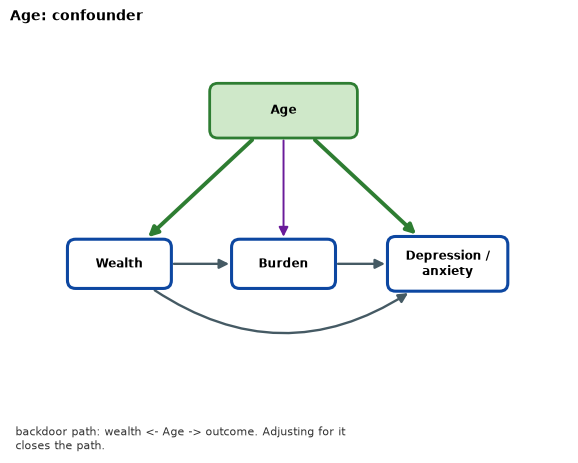

In [8]:
examine("Age", causes_wealth="yes", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="sits before everything and reaches wealth, burden and mental health")

### 4.2 Division (V024)

Where she lives among the eight divisions. Regional economies differ, so household wealth differs. Schooling, health services, norms and the way symptoms are reported differ too. It is fixed long before the survey and wealth does not move a household to another division in any way that matters here. Confounder.

It is also part of the design: division and residence together make up the 16 sampling strata (we check that in section 6), so it stays in the model whatever we conclude here.

Division (V024): administrative division, 8 levels



,level,women,share
0,Barishal,548,0.112
1,Chattogram,736,0.151
2,Dhaka,700,0.143
3,Khulna,628,0.129
4,Mymensingh,533,0.109
5,Rajshahi,621,0.127
6,Rangpur,586,0.120
7,Sylhet,535,0.109


association with wealth 0.14, with burden 0.05 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: confounder
what we do: adjust
burden side: also confounds burden and outcome


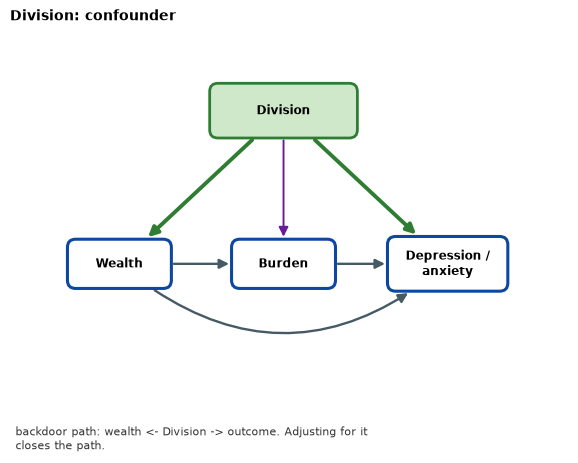

In [9]:
examine("Division", causes_wealth="yes", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="regional economy and norms, and it is also a sampling stratum")

### 4.3 Residence (V025)

Urban or rural. Urban households hold more assets and services, and the wealth index carries that, so residence pushes wealth. It also changes mental health (stressors and support are different) and burden (diet and physical activity).

There is a reverse story: people get richer and move to town. For a married woman interviewed in her own household that looks smaller than the structural urban and rural gap, so we say wealth does not cause it. If we are wrong the label changes, but the variable stays anyway because it is a sampling stratum. Confounder.

Residence (V025): urban or rural



,level,women,share
0,urban,1709,0.35
1,rural,3178,0.65


association with wealth 0.40, with burden 0.12 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: confounder
what we do: adjust
burden side: also confounds burden and outcome


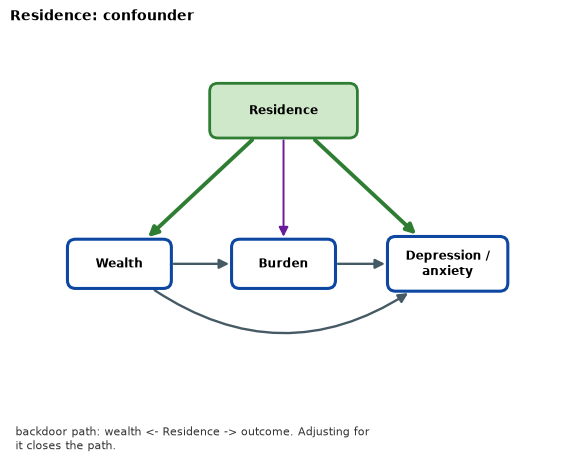

In [10]:
examine("Residence", causes_wealth="yes", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="urban and rural gap in assets and services, and it is also a sampling stratum")

### 4.4 Religion (V130)

Islam or others. Settled long before household wealth. Religious groups differ in schooling and in wealth, and norms about marriage, family and how mental health is understood differ as well, so it reaches wealth and the outcome. Wealth does not cause it.

Confounder, probably a weak one here since only about one woman in ten is in the other group. It costs one degree of freedom, which is cheap.

Religion (V130): Islam or others



,level,women,share
0,Islam,4391,0.899
1,others,496,0.101


association with wealth 0.02, with burden 0.03 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: confounder
what we do: adjust
burden side: also confounds burden and outcome


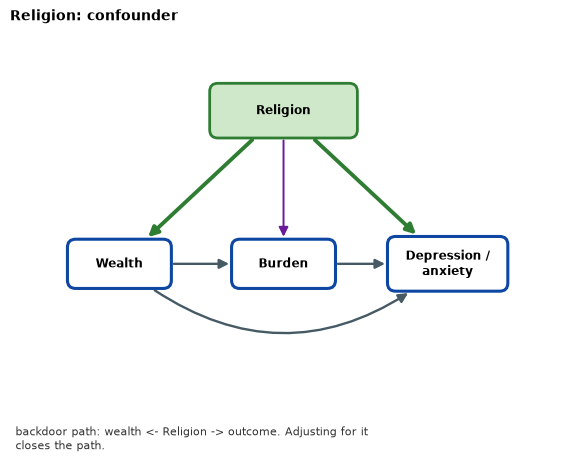

In [11]:
examine("Religion", causes_wealth="yes", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="fixed early, differs in wealth and in norms around mental health, probably weak here")

### 4.5 Education (V106)

Highest level attained. Most women finished school long before the household wealth we measure today was built. Schooling leads to better paid work for her and, through who she marries, for the household, so it pushes wealth. It also affects mental health directly (coping resources, health knowledge, how she is treated at home) and burden.

The reverse route, wealth paying for schooling, is real, but it runs through her parents' wealth and not through the wealth of the household she lives in now. Parents' wealth is one of the things we can not measure, and education stands in for part of it. Depression in adolescence could cut schooling short, but we treat that as small. Confounder.

Education (V106): highest level attained



,level,women,share
0,no education,659,0.135
1,primary,1276,0.261
2,secondary,2172,0.444
3,higher,780,0.160


association with wealth 0.26, with burden 0.04 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: confounder
what we do: adjust
burden side: also confounds burden and outcome


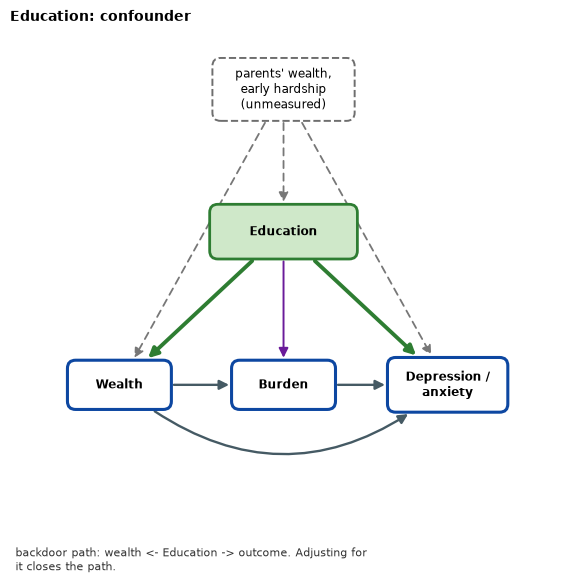

In [12]:
examine("Education", causes_wealth="yes", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        hidden=("parents' wealth,\nearly hardship\n(unmeasured)", "top", ["C", "W", "Y"]),
        why="finished before current wealth, moves wealth and mental health")

### 4.6 Age at first cohabitation (V511)

It is measured years before the current wealth, so wealth can not have caused it. Marrying early goes with worse mental health later, so it reaches the outcome.

Does it cause wealth? Not obviously. The more honest description is that it is a marker of something that does. Poverty in her parents' household pushes girls into early marriage, and it also shapes the wealth she ends up with. We can not measure early life poverty, and age at marriage is the closest stand-in we have. That makes it a proxy, not a strict confounder. Nothing forces us to adjust for it, we would add it as a stand-in.

Age at first cohabitation (V511): age when she started living with her husband



,level,women,share
0,<15,1351,0.276
1,15-24,3334,0.682
2,25-34,193,0.039
3,35-49,9,0.002


association with wealth 0.11, with burden 0.04 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      unclear
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: proxy
what we do: adjust, as a stand-in
burden side: -


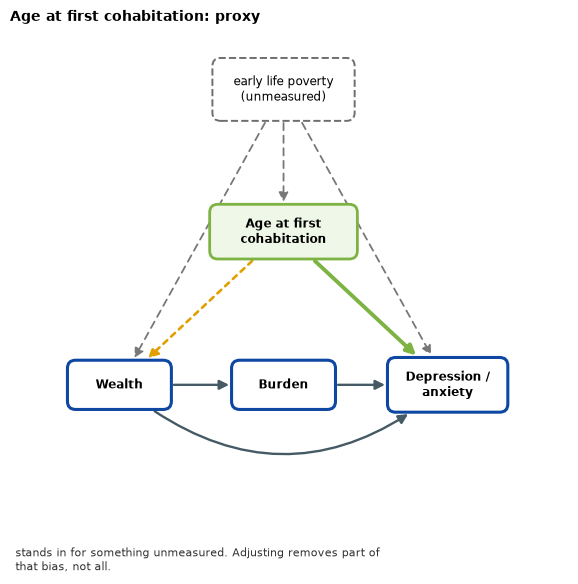

In [13]:
examine("AgeAtCohabitation", causes_wealth="unclear", caused_by_wealth="no", causes_outcome="yes",
        proxy_for="early life poverty",
        hidden=("early life poverty\n(unmeasured)", "top", ["C", "W", "Y"]),
        why="years before current wealth, and a stand-in for early life poverty")

### 4.7 Occupation (V714)

Whether she is working at the time of the survey. We went back and forth on this one, because both stories are believable.

The ordering we use in this project is education, then occupation, then wealth: schooling leads to work, and her earnings add to household assets. Under that story work comes before wealth, and it also changes her stress and her independence, so it is a confounder.

The other story is that richer households keep women out of paid work while poor households push them into it. Then wealth causes work, and work becomes a mediator. Cross-sectional data can not tell these apart. There is a second wrinkle: depression can also keep a woman out of work, which would make it a collider as well if wealth causes it.

We follow our project ordering, treat it as a confounder, and flip it in a sensitivity model.

Occupation (V714): is she working now



,level,women,share
0,not working,3369,0.689
1,working,1518,0.311


association with wealth 0.13, with burden 0.03 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       unclear
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         unclear
   does it cause burden?                                      no
   can burden cause it?                                       no
   contested, we lean towards: before

verdict: confounder (contested, the other reading is mediator)
what we do: adjust (primary), drop in a sensitivity model
burden side: -
watch out: depression can keep women out of work (reverse causation)


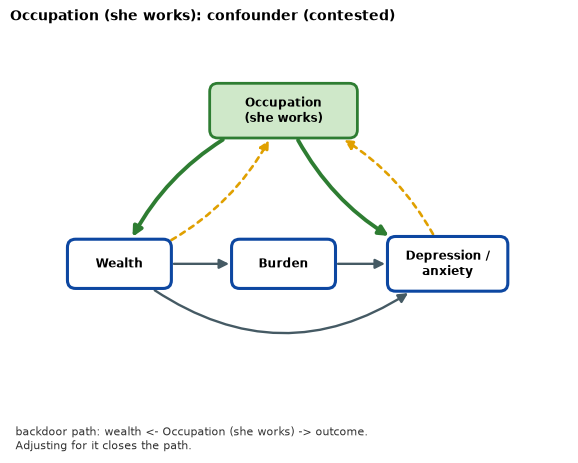

In [14]:
examine("Occupation", causes_wealth="yes", caused_by_wealth="unclear", causes_outcome="yes", caused_by_outcome="unclear",
        lean="before",
        caveat="depression can keep women out of work (reverse causation)",
        why="on our ordering (education, occupation, wealth) it comes before wealth, but the reverse story is possible")

### 4.8 Partner occupation (V705)

His work status. His job is one of the main sources of household assets, so it reaches wealth. Wealth does not decide what job he has, at least not in a way we care about here.

The open question is whether it reaches her mental health by a route that does not go through money. Job insecurity, long absences and working abroad could all do that, and it also stands in for his education and income stability, which we can not measure. If that link exists it is a confounder. If it only acts through money it is instrument-like, and adjusting for it buys nothing. We lean towards yes.

One warning from the data: as coded, nearly every husband is in the 'working' group, so there is very little variation to adjust with.

Partner occupation (V705): husband's work status



,level,women,share
0,not working,145,0.030
1,working,4734,0.969
2,don't know,8,0.002


association with wealth 0.05, with burden 0.05 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      yes
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    unclear
   can depression / anxiety cause it?                         no
   does it cause burden?                                      no
   can burden cause it?                                       no
   contested, we lean towards: yes

verdict: confounder (contested, the other reading is instrument-like)
what we do: adjust (primary), drop in a sensitivity model
burden side: -


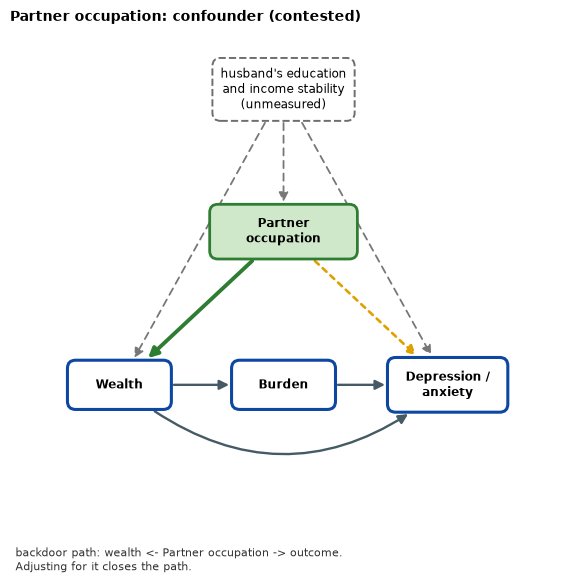

In [15]:
examine("PartnerOccupation", causes_wealth="yes", caused_by_wealth="no", causes_outcome="unclear", lean="yes",
        hidden=("husband's education\nand income stability\n(unmeasured)", "top", ["C", "W", "Y"]),
        why="main source of household assets, a confounder only if it also touches her mental health directly")

### 4.9 Family size (V136)

Household members, split at 5. It can go both ways. A bigger household can mean more earners and more assets. A richer household can also keep a large joint household together. And the count includes her own children, which depend on wealth and education (next candidate).

It reaches the outcome (crowding and conflict with in-laws, but also support). Because it partly counts her children, we lean towards it coming after wealth, which makes it a mediator we should not adjust for in the main model. Contested, so it goes into a sensitivity model.

Family size (V136): household members, under 5 or 5 and over



,level,women,share
0,under 5,2277,0.466
1,5 or more,2610,0.534


association with wealth 0.03, with burden 0.08 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      unclear
   can wealth cause it?                                       unclear
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      no
   can burden cause it?                                       no
   contested, we lean towards: after

verdict: mediator (contested, the other reading is confounder)
what we do: leave out of primary, add in a sensitivity model
burden side: -


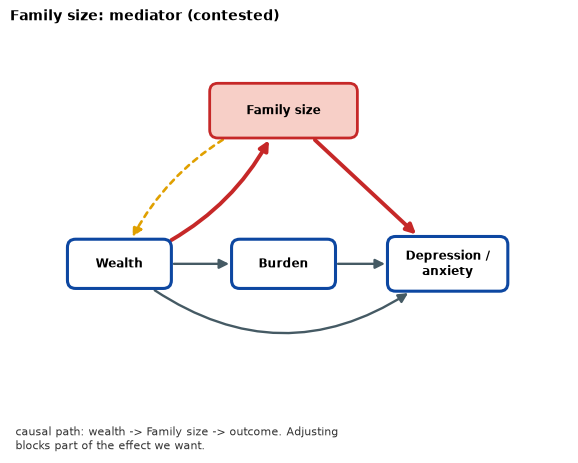

In [16]:
examine("FamilySize", causes_wealth="unclear", caused_by_wealth="unclear", causes_outcome="yes", lean="after",
        why="counts her children, and wealth may shape it as much as it shapes wealth")

### 4.10 Children (V201)

Children ever born, top-coded at 4. It depends on age, education and age at marriage. It also depends on household resources over the years, because fertility choices respond to money, so wealth plausibly causes it. In the other direction a large family can drain savings and hold wealth down.

It affects mental health (the care load) and burden (weight and blood pressure after pregnancies). Timing is unclear. We lean towards after wealth, so it is a mediator for the total effect, and we keep the other reading for a sensitivity model. It is also a confounder of burden and the outcome, so it comes back on the burden side.

Children (V201): children ever born, top-coded at 4



,level,women,share
0,none,418,0.086
1,1,1066,0.218
2,2,1594,0.326
3,3,1038,0.212
4,4 or more,771,0.158


association with wealth 0.10, with burden 0.09 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      unclear
   can wealth cause it?                                       unclear
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no
   contested, we lean towards: after

verdict: mediator (contested, the other reading is confounder)
what we do: leave out of primary, add in a sensitivity model
burden side: confounds burden and outcome (timing unclear)


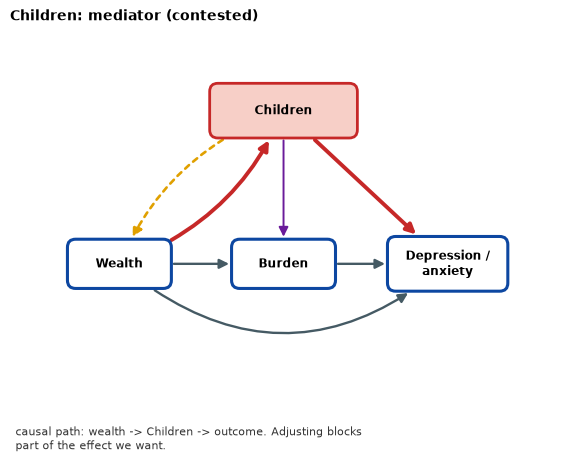

In [17]:
examine("Children", causes_wealth="unclear", caused_by_wealth="unclear", causes_outcome="yes", causes_burden="yes", lean="after",
        why="wealth and education shape fertility, and it also confounds burden and outcome")

### 4.11 Household Autonomy (V743A, V743B, V743D)

How many of three household decisions she has a say in: her own health care, large purchases, visits to family. It follows from education, age, work and household circumstances. Wealth feeds into it too, since it is easier to have a say in a household that has something to decide about. We do not see how it builds household assets, so it does not cause wealth. It does affect mental health.

So wealth, then autonomy, then mental health is exactly the kind of pathway we want to keep inside the effect. Mediator.

There is a second problem. Autonomy is partly a marker of gender norms and control at home, which we can not measure and which also affect mental health. Adjusting for something that wealth and those norms both cause opens a path between them. And depression could lower a woman's say at home, so it may be an effect of the outcome as well.

Household Autonomy (V743A/B/D): number of 3 household decisions she has a say in



,level,women,share
0,no say in any of the three,746,0.153
1,say in one,593,0.121
2,say in two,674,0.138
3,say in all three,2874,0.588


association with wealth 0.04, with burden 0.04 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         unclear
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: -
watch out: depression could lower her say at home, and norms we can not measure sit behind it


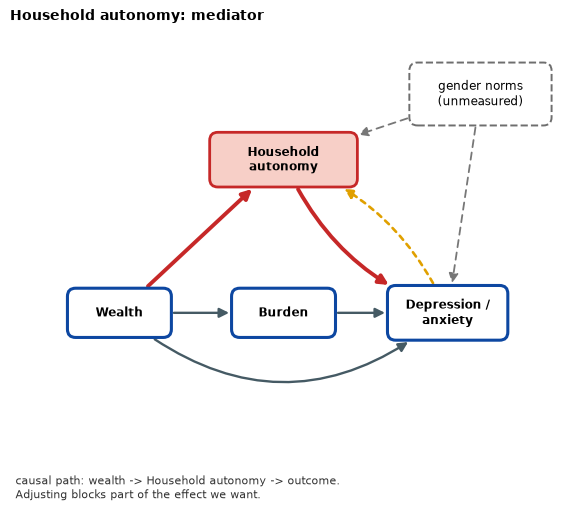

In [18]:
examine("Autonomy", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes", caused_by_outcome="unclear",
        hidden=("gender norms\n(unmeasured)", "right", ["C", "Y"]),
        caveat="depression could lower her say at home, and norms we can not measure sit behind it",
        why="follows from wealth, education and work, so it is part of how wealth works")

### 4.12 Financial Decision-Making (V743F)

Whether she has a say in how the money her husband earns is spent, with a separate level for husbands with no earnings, which is why it was kept apart from autonomy. Same story as autonomy and even closer to money: wealth changes how much there is to decide about and who decides, and financial control affects mental health. Mediator, with the same warning about the norms we can not measure.

Financial Decision-Making (V743F): say in how her husband's earnings are spent



,level,women,share
0,no say,1585,0.324
1,has a say,3238,0.663
2,husband has no earnings,64,0.013


association with wealth 0.04, with burden 0.05 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         unclear
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: -
watch out: same as autonomy: norms we can not measure sit behind it


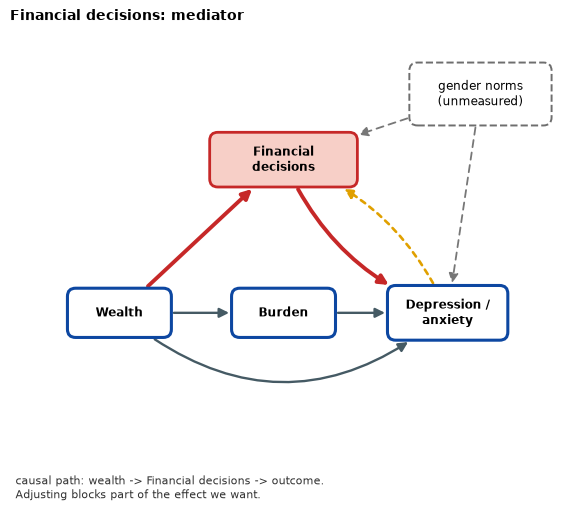

In [19]:
examine("FinDecision", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes", caused_by_outcome="unclear",
        hidden=("gender norms\n(unmeasured)", "right", ["C", "Y"]),
        caveat="same as autonomy: norms we can not measure sit behind it",
        why="same as autonomy, and even closer to money")

### 4.13 IPV Attitude (V744A to V744E)

Whether she thinks a husband can be justified in hitting his wife in some situation, with a separate level for 'don't know'. An attitude, shaped by schooling, age, region and religion, and by what the household looks like. Wealth probably shifts it a little, so the link from wealth is weaker than for autonomy. Accepting violence goes with worse mental health.

We call it a mediator, a weak one, and it is another marker of norms.

IPV Attitude (V744A-E): whether she thinks a husband can be justified in hitting his wife



,level,women,share
0,rejects in all scenarios,4174,0.854
1,uncertain,62,0.013
2,justifies in one or more,651,0.133


association with wealth 0.06, with burden 0.02 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: -


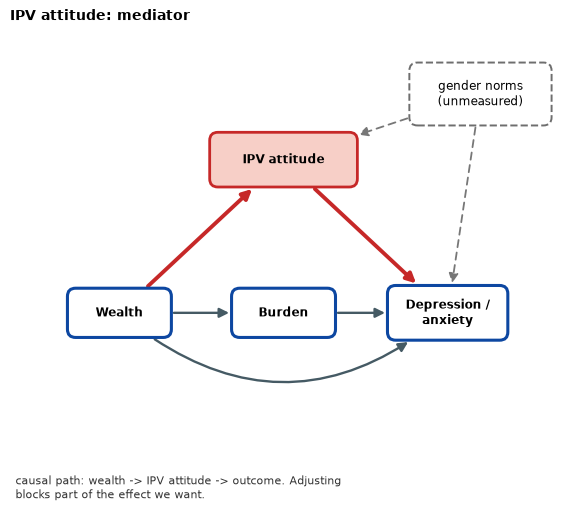

In [20]:
examine("IPVattitude", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes",
        hidden=("gender norms\n(unmeasured)", "right", ["C", "Y"]),
        why="attitude shaped by schooling and household circumstances, weak downstream of wealth")

### 4.14 Insurance (V481)

Covered by health insurance. Being covered takes work, money or a programme, so it follows wealth, and financial protection could help mental health. A mediator on paper.

The more useful fact is in the data. Only 16 women in the sample are insured, so there is almost nothing to estimate, and in the models it separates the outcome completely. It leaves whatever the label says.

Insurance (V481): covered by health insurance



,level,women,share
0,no,4871,0.997
1,yes,16,0.003


association with wealth 0.05, with burden 0.02 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: -


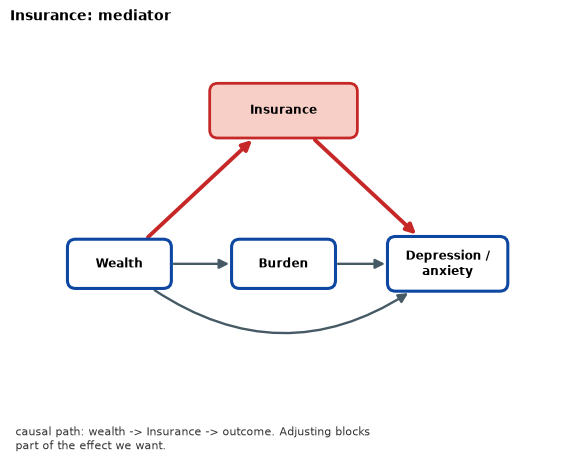

In [21]:
examine("Insurance", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes",
        why="follows from money and work, and only 16 women are insured")

### 4.15 Mass Media (V171A, V159)

**Renamed from "Internet" -- now combines whether she has used the internet (V171A) with whether and how often she watches television (V159) into one four-level measure: neither, TV only, internet only, or both. This changes the wealth-causation story below, which was written for internet alone; flagged for a second look rather than re-decided here.**

The internet half needs a device, data and money and follows schooling and age, so wealth causes it. Television is far more widely owned in Bangladeshi households, regardless of the woman's own means, so folding it in loosens that link somewhat. It can affect mental health in both directions (contact and information, but also exposure). Mediator.

Depressed women might also use TV or the internet more, so it could be an effect of the outcome too, which would be a collider risk.

Mass Media (V171A, V159): TV and/or internet use



,level,women,share
0,neither,1674,0.343
1,television only,1808,0.370
2,internet only,498,0.102
3,both television and internet,907,0.186


association with wealth 0.30, with burden 0.05 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         unclear
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: -
watch out: depressed women may use TV or the internet more (reverse causation); combining TV with internet may loosen the wealth link, revisit if needed


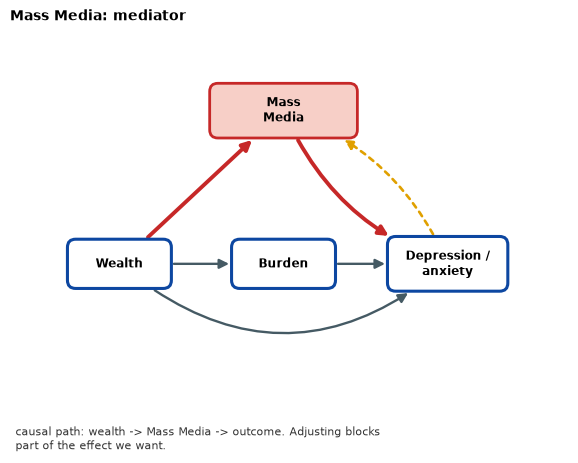

In [22]:
examine("MassMedia", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes", caused_by_outcome="unclear",
        caveat="depressed women may use TV or the internet more (reverse causation); combining TV with internet may loosen the wealth link, revisit if needed",
        why="internet needs money, a device and data; TV is far more universal")

### 4.16 Contraceptive (V313)

Method in use: none, folkloric, traditional or modern. Wealth and education change access and cost, so wealth causes it. It can change mood (hormonal methods, or fewer unwanted pregnancies) and weight and blood pressure, so it reaches the outcome and burden. A mediator of the wealth effect.

Because it causes burden too it matters on the burden side, but there it is caused by wealth, which is awkward: adjusting for it fixes the burden link and blocks part of wealth's own effect at the same time. One level (folkloric) has only a handful of women and would need collapsing before use.

Contraceptive (V313): method in use



,level,women,share
0,no method,1676,0.343
1,folkloric,5,0.001
2,traditional,517,0.106
3,modern,2689,0.550


association with wealth 0.07, with burden 0.04 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: confounds burden and outcome, but wealth causes it too


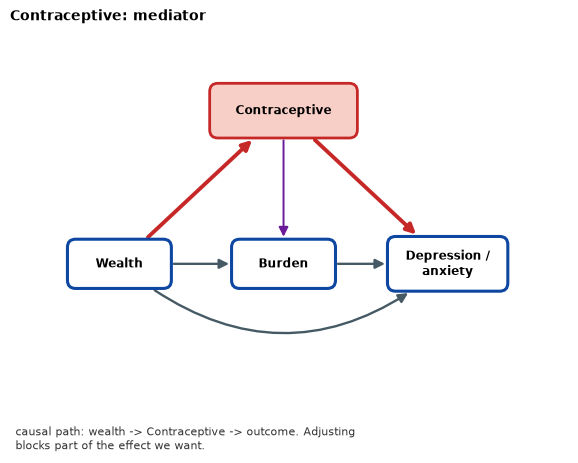

In [23]:
examine("Contraception", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes", causes_burden="yes",
        why="wealth changes access, and it changes mood and burden")

### 4.17 Abortion (V228)

Ever had a terminated pregnancy. In the DHS item this covers miscarriage, abortion and stillbirth, so the label is narrower than what is measured. Wealth, education and contraceptive use change whether pregnancies are wanted and whether they go to term, and a loss can hit mood. Wealth, then this, then the outcome: a mediator.

Abortion (V228): ever had a terminated pregnancy



,level,women,share
0,no,3616,0.74
1,yes,1271,0.26


association with wealth 0.02, with burden 0.05 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       yes
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      no
   can burden cause it?                                       no

verdict: mediator
what we do: leave out of the total effect model
burden side: -


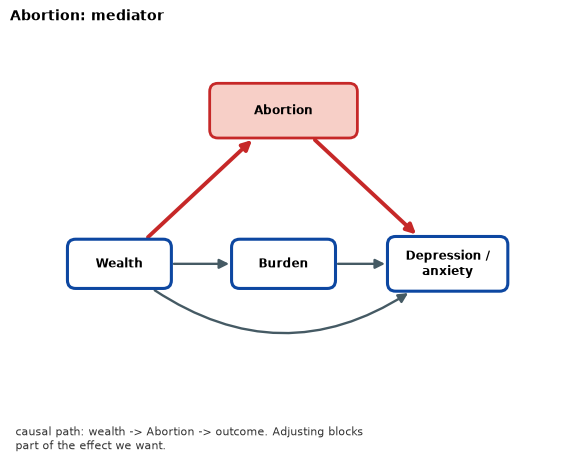

In [24]:
examine("Abortion", causes_wealth="no", caused_by_wealth="yes", causes_outcome="yes",
        why="wealth and education change whether pregnancies are wanted and end, and a loss can hit mood")

### 4.18 Pregnant (V213)

Currently pregnant. A snapshot, mostly a matter of age. Wealth does not cause being pregnant this month in any way that matters here (over a lifetime it shapes family size, but that is the children variable), and being pregnant does not cause wealth. It does change blood pressure and glucose, so burden, and mood, so the outcome.

It reaches the outcome and burden but not wealth. For the wealth effect it is a cause of the outcome only: harmless to add, but it removes no bias. It matters on the burden side.

Pregnant (V213): currently pregnant



,level,women,share
0,no or unsure,4601,0.941
1,yes,286,0.059


association with wealth 0.01, with burden 0.07 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: precision
what we do: not needed for bias, harmless
burden side: also confounds burden and outcome


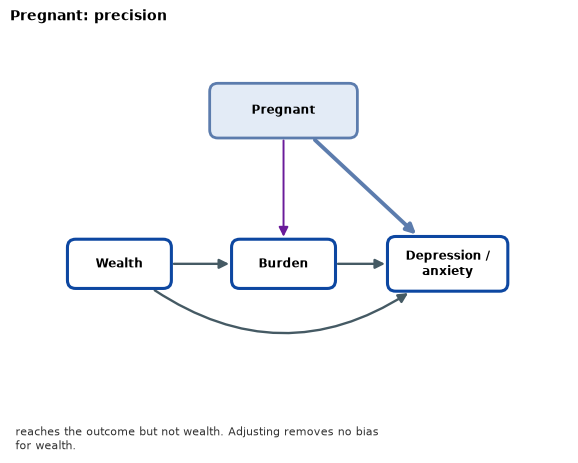

In [25]:
examine("Pregnant", causes_wealth="no", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="life stage, changes blood pressure, glucose and mood, not caused by wealth")

### 4.19 Postpartum (V536)

Not sexually active because of a recent birth. It comes from the same raw item as sexual activity, so it is a crude marker of recent delivery and only catches women who are abstaining for that reason. Same reasoning as pregnant: it changes mood, weight and blood pressure, and it has nothing to do with wealth. It also feeds straight into sexual activity because they share the item.

Postpartum (V536): not sexually active because of a recent birth



,level,women,share
0,no,4770,0.976
1,yes,117,0.024


association with wealth 0.03, with burden 0.05 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: precision
what we do: not needed for bias, harmless
burden side: also confounds burden and outcome


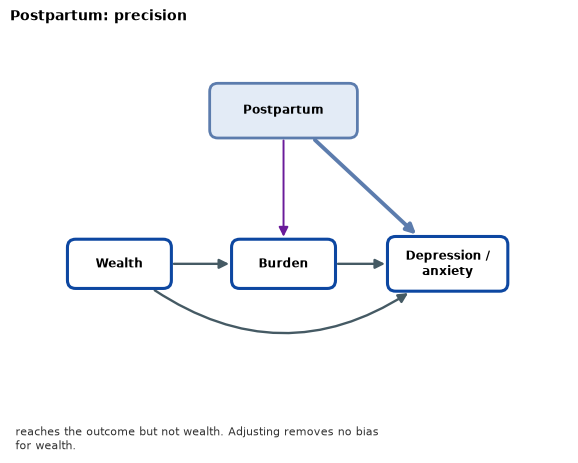

In [26]:
examine("Postpartum", causes_wealth="no", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="same item as sexual activity, same story as pregnant")

### 4.20 Menopause (V226)

In menopause. Mostly age, but not only age. It changes weight, blood pressure and mood. Wealth does not cause it and it does not cause wealth, so it does not confound the wealth effect. Same class as pregnant. It overlaps heavily with age, which is one more reason not to stack it on top of age in the main model.

Menopause (V226): in menopause



,level,women,share
0,no,4621,0.946
1,yes,266,0.054


association with wealth 0.04, with burden 0.11 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    yes
   can depression / anxiety cause it?                         no
   does it cause burden?                                      yes
   can burden cause it?                                       no

verdict: precision
what we do: not needed for bias, harmless
burden side: also confounds burden and outcome


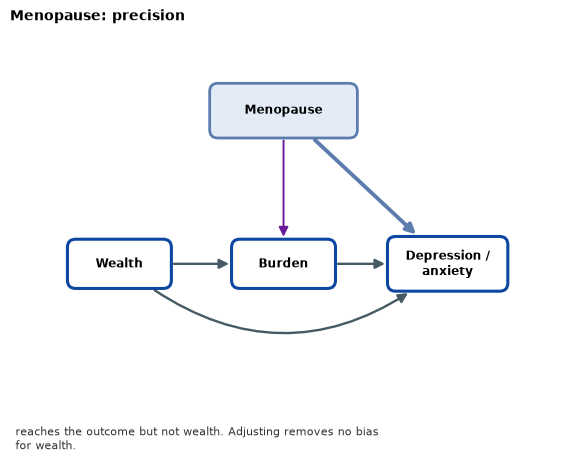

In [27]:
examine("Menopause", causes_wealth="no", caused_by_wealth="no", causes_outcome="yes", causes_burden="yes",
        why="mostly age, changes weight, blood pressure and mood, not caused by wealth")

### 4.21 Sexual activity (V536)

Active in the last four weeks. Two things push it down: cardiometabolic illness (pain, tiredness, medication) and depression or anxiety (loss of interest). Two arrows meet in it, burden into activity and the outcome into activity. That is the textbook collider, and it also sits downstream of wealth through burden.

Adjusting for it opens a path between burden and the outcome that is not causal, which would distort exactly the interaction we are after. Never adjust. It also has a coding problem: 'not active' mixes never had sex, postpartum abstinence and abstaining.

Sexual activity (V536): sexually active in the last 4 weeks



,level,women,share
0,not active,957,0.196
1,active,3930,0.804


association with wealth 0.08, with burden 0.02 (Cramer's V, descriptive only)

our answers
   does it cause wealth (or sit before it and reach it)?      no
   can wealth cause it?                                       no
   does it reach depression / anxiety, not through wealth?    no
   can depression / anxiety cause it?                         yes
   does it cause burden?                                      no
   can burden cause it?                                       yes

verdict: collider
what we do: never adjust
burden side: -


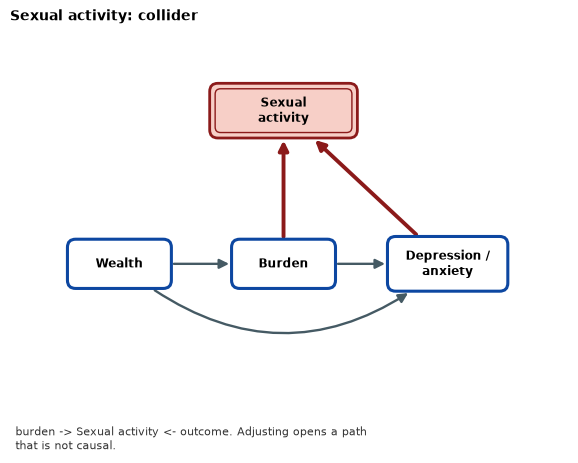

In [28]:
examine("SexualActivity", causes_wealth="no", caused_by_wealth="no", causes_outcome="no", caused_by_outcome="yes",
        caused_by_burden="yes",
        why="burden and the outcome both lower it, so two arrows meet there")

## 5. Putting the answers together

Everything below is built from what `examine()` stored. Nothing is typed in again.

In [29]:
ORDER = ["confounder", "proxy", "mediator", "precision", "collider", "effect of the outcome",
         "instrument-like", "irrelevant descendant", "unrelated"]

summary = pd.DataFrame(
    [{"candidate": r["column"], "label": r["cls"], "contested": ("yes, other reading: " + r["alt"]) if r["alt"] else "",
      "what we do": r["decision"], "burden side": r["burden"], "why": r["why"]} for r in RESULTS.values()]
)
summary["rank"] = summary["label"].map({c: i for i, c in enumerate(ORDER)})
summary = summary.sort_values(["rank", "contested"], kind="stable").drop(columns="rank").reset_index(drop=True)
summary

,candidate,label,contested,what we do,burden side,why
0,Age,confounder,,adjust,also confounds burden and outcome,"sits before everything and reaches wealth, burden and mental health"
1,Division,confounder,,adjust,also confounds burden and outcome,"regional economy and norms, and it is also a sampling stratum"
2,Residence,confounder,,adjust,also confounds burden and outcome,"urban and rural gap in assets and services, and it is also a sampling stratum"
3,Religion,confounder,,adjust,also confounds burden and outcome,"fixed early, differs in wealth and in norms around mental health, probably weak here"
4,Education,confounder,,adjust,also confounds burden and outcome,"finished before current wealth, moves wealth and mental health"
5,Partner occupation,confounder,"yes, other reading: instrument-like","adjust (primary), drop in a sensitivity model",-,"main source of household assets, a confounder only if it also touches her mental health directly"
6,Occupation,confounder,"yes, other reading: mediator","adjust (primary), drop in a sensitivity model",-,"on our ordering (education, occupation, wealth) it comes before wealth, but the reverse story is possible"
7,Age at first cohabitation,proxy,,"adjust, as a stand-in",-,"years before current wealth, and a stand-in for early life poverty"
8,Household Autonomy,mediator,,leave out of the total effect model,-,"follows from wealth, education and work, so it is part of how wealth works"
9,Financial Decision-Making,mediator,,leave out of the total effect model,-,"same as autonomy, and even closer to money"


In [30]:
counts = pd.Series([("contested " if r["alt"] else "") + r["cls"] for r in RESULTS.values()]).value_counts()
print(counts.to_string())
print("total:", counts.sum())

mediator                7
confounder              5
precision               3
contested confounder    2
contested mediator      2
proxy                   1
collider                1
total: 21


In [31]:
def names(nodes):
    return ", ".join(COLUMN[n] for n in nodes) or "-"


primary = [n for n, r in RESULTS.items() if r["cls"] in ("confounder", "proxy")]
contested_confounders = [n for n in primary if RESULTS[n]["alt"]]
contested_mediators = [n for n, r in RESULTS.items() if r["cls"] == "mediator" and r["alt"] == "confounder"]
burden_extra = [n for n, r in RESULTS.items() if r["burden"] != "-" and n not in primary]

# the empowerment and access mediators as one exploratory block. Insurance stays out on purpose (16 insured women)
S2_EXTRA = ["Autonomy", "FinDecision", "IPVattitude", "MassMedia"]
assert all(RESULTS[n]["cls"] == "mediator" for n in S2_EXTRA)

blocks = {
    "primary": primary,
    "S1a: add the contested mediators": primary + contested_mediators,
    "S1b: drop the contested confounders": [n for n in primary if n not in contested_confounders],
    "S2: add the empowerment and access mediators": primary + S2_EXTRA,
    "S3: add the burden side confounders": primary + burden_extra,
}

print(f"primary set ({len(primary)}): {names(primary)}")
print("   contested inside it:", names(contested_confounders))
print("contested mediators (S1a):", names(contested_mediators))
print("burden side extras (S3):  ", names(burden_extra))

primary set (8): Age, Division, Residence, Religion, Education, Age at first cohabitation, Occupation, Partner occupation
   contested inside it: Occupation, Partner occupation
contested mediators (S1a): Family size, Children
burden side extras (S3):   Children, Contraceptive, Pregnant, Postpartum, Menopause


### One picture

The same result as a DAG, built only from the labels. Each box holds the candidates that got that label. A star marks a contested call.

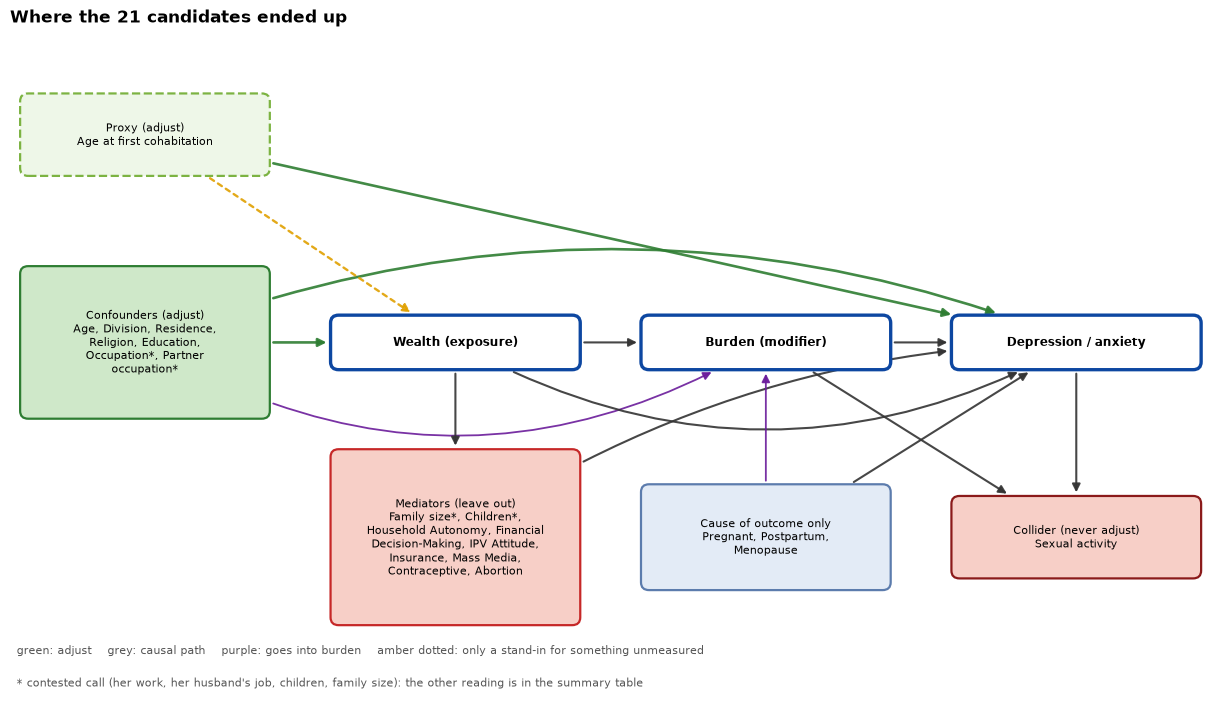

In [32]:
GROUPS = {
    "proxy":      ("Proxy (adjust)",             (1.8, 7.0)),
    "confounder": ("Confounders (adjust)",       (1.8, 3.8)),
    "mediator":   ("Mediators (leave out)",      (6.4, 0.8)),
    "precision":  ("Cause of outcome only",      (11.0, 0.8)),
    "collider":   ("Collider (never adjust)",    (15.6, 0.8)),
    "other":      ("Other",                      (11.0, 7.0)),
}
MAIN = {"W": ("Wealth (exposure)", (6.4, 3.8)), "B": ("Burden (modifier)", (11.0, 3.8)), "Y": ("Depression / anxiety", (15.6, 3.8))}
GROUP_COLOR = {"confounder": "confounder", "proxy": "proxy", "mediator": "mediator", "precision": "precision",
               "collider": "collider", "other": "instrument-like"}

# (from, to, style, curvature). same idea as the small pictures: who causes what, by label.
# the long ones are curved on purpose so they do not run behind other boxes
SUMMARY_ARROWS = [
    ("confounder", "W", "adj", 0.0), ("confounder", "Y", "adj", -0.2), ("confounder", "B", "side", 0.3),
    ("proxy", "Y", "adj", 0.0), ("proxy", "W", "maybe", 0.0),
    ("W", "B", "core", 0.0), ("B", "Y", "core", 0.0), ("W", "Y", "core", 0.28),
    ("W", "mediator", "core", 0.0), ("mediator", "Y", "core", -0.15),
    ("precision", "Y", "core", 0.0), ("precision", "B", "side", 0.0),
    ("B", "collider", "core", 0.0), ("Y", "collider", "core", 0.0),
]


def draw_summary(ax):
    ax.set_xlim(-0.2, 17.6)
    ax.set_ylim(-1.6, 8.6)
    ax.axis("off")
    ax.set_title("Where the 21 candidates ended up", loc="left", fontsize=12, fontweight="bold")
    members = {}
    for n, r in RESULTS.items():
        members.setdefault(r["cls"] if r["cls"] in GROUPS else "other", []).append(n)
    boxes, pos = {}, {}
    for key, (title, xy) in GROUPS.items():
        if key not in members:
            continue
        # a star marks the contested calls
        listed = ", ".join(COLUMN[n] + ("*" if RESULTS[n]["alt"] else "") for n in members[key])
        text = title + "\n" + textwrap.fill(listed, 30)
        w, h = 3.7, 0.55 + 0.36 * (text.count("\n") + 1)
        fc, ec = CLASS_INFO[GROUP_COLOR[key]]["color"]
        p = FancyBboxPatch((xy[0] - w / 2, xy[1] - h / 2), w, h, boxstyle="round,pad=0,rounding_size=0.12", fc=fc, ec=ec,
                           lw=1.6, ls="--" if key == "proxy" else "-", zorder=3)
        ax.add_patch(p)
        ax.text(xy[0], xy[1], text, ha="center", va="center", fontsize=7.8, zorder=5, linespacing=1.25)
        boxes[key], pos[key] = p, xy
    for key, (title, xy) in MAIN.items():
        p = FancyBboxPatch((xy[0] - 1.85, xy[1] - 0.42), 3.7, 0.84, boxstyle="round,pad=0,rounding_size=0.12", fc="#ffffff",
                           ec="#0d47a1", lw=2.4, zorder=3)
        ax.add_patch(p)
        ax.text(xy[0], xy[1], title, ha="center", va="center", fontsize=8.4, fontweight="bold", zorder=5)
        boxes[key], pos[key] = p, xy
    look = {"adj": ("#2e7d32", 1.9, "-"), "core": ("#333333", 1.5, "-"), "side": ("#6a1b9a", 1.3, "-"),
            "maybe": ("#e0a000", 1.7, (0, (2, 2)))}
    for a, b, kind, rad in SUMMARY_ARROWS:
        if a not in boxes or b not in boxes:
            continue
        col, lw, ls = look[kind]
        ax.add_patch(FancyArrowPatch(pos[a], pos[b], arrowstyle="-|>", mutation_scale=12, lw=lw, color=col, ls=ls, alpha=0.9,
                                     connectionstyle=f"arc3,rad={rad}", patchA=boxes[a], patchB=boxes[b],
                                     shrinkA=2, shrinkB=2, zorder=2))
    ax.text(-0.1, -1.0, "green: adjust    grey: causal path    purple: goes into burden    amber dotted: only a stand-in for something unmeasured",
            fontsize=8, color="#555555")
    ax.text(-0.1, -1.5, "* contested call (her work, her husband's job, children, family size): the other reading is in the summary table",
            fontsize=8, color="#555555")


fig, ax = plt.subplots(figsize=(15.5, 8.6))
draw_summary(ax)
fig_summary = fig
plt.show()

## 6. Can the sets be fitted?

Nothing here changes a label. It only checks that what we ended up with can be estimated with 4,887 women and a couple of hundred events.

In [33]:
# df per covariate straight from the file
df_of = {n: df_depression[COLUMN[n]].nunique() - 1 for n in CANDIDATES if COLUMN[n] in df_depression.columns}

wealth_df = df_depression["Socioeconomic Status"].nunique() - 1
focal = wealth_df + 1 + wealth_df      # wealth, burden as a single linear term, wealth x burden
events = {"depression": int(df_depression["Y"].sum()), "anxiety": int(df_anxiety["Y"].sum())}

rows = []
for name, zs in blocks.items():
    cov_df = sum(df_of[v] for v in zs)
    params = focal + cov_df
    rows.append({"model": name, "covariates": len(zs), "covariate df": cov_df, "parameters": params,
                 "events per parameter (depression)": round(events["depression"] / params, 1),
                 "events per parameter (anxiety)": round(events["anxiety"] / params, 1)})
print("parameters outside the covariates: wealth (4) + burden linear (1) + wealth x burden (4) =", focal)
pd.DataFrame(rows)

parameters outside the covariates: wealth (4) + burden linear (1) + wealth x burden (4) = 9


,model,covariates,covariate df,parameters,events per parameter (depression),events per parameter (anxiety)
0,primary,8,20,29,8.1,7.6
1,S1a: add the contested mediators,10,25,34,6.9,6.5
2,S1b: drop the contested confounders,6,17,26,9.0,8.5
3,S2: add the empowerment and access mediators,12,30,39,6.0,5.7
4,S3: add the burden side confounders,13,30,39,6.0,5.7


In [34]:
# division and residence together are the sampling strata, so they stay in the model on design grounds too
per_stratum = df_depression.groupby("Stratum")[["Division", "Residence"]].nunique()
print("strata:", df_depression["Stratum"].nunique())
print("strata that mix more than one division-by-residence cell:", int((per_stratum.max(axis=1) > 1).sum()))
print("division-by-residence cells:", df_depression.groupby(["Division", "Residence"]).ngroups)

# positivity for the two strongest confounders of wealth
print("\nwealth by residence:")
print(pd.crosstab(df_depression["Socioeconomic Status"], df_depression["Residence"]))
print("\nwealth by education:")
print(pd.crosstab(df_depression["Socioeconomic Status"], df_depression["Education"]))

strata: 16
strata that mix more than one division-by-residence cell: 0
division-by-residence cells: 16

wealth by residence:
Residence               1    2
Socioeconomic Status          
1                      93  766
2                     178  766
3                     297  647
4                     419  597
5                     722  402

wealth by education:
Education               0    1    2    3
Socioeconomic Status                    
1                     220  342  281   16
2                     172  314  404   54
3                     122  262  462   98
4                      90  231  520  175
5                      55  127  505  437


## 7. What is left

We started with 21 candidates and no number in mind. Seven came out as confounders (age, division, residence, religion, education, her work and her husband's job), one as a proxy (age at first cohabitation), nine as mediators (two of them with unclear timing), three as life stage variables that matter only on the burden side, and one as a collider. That makes 8 covariates for the main model.

Things to keep in mind when we write this up:

- Four calls are contested: her work, her husband's job, children and family size. That is what the sensitivity models are for. S1b drops the two contested confounders, S1a adds the two contested mediators.
- Burden is downstream of wealth in our story, so the wealth term in a model that also contains burden is not a total effect. We should describe the product term as effect modification, not causal interaction. The burden side variables (S3) show how much depends on that.
- Some confounding can not be removed: early life SES, husband's education, lifestyle. We report E-values and say so in the limitations.
- Report the wealth, burden and product terms only. Coefficients for covariates chosen this way are not effects we can interpret.

Before the main models: re-derive age at a finer scale than 3 bands (`V012`, or the 5 year bands in `V013`), and recode partner occupation into a few occupational classes or drop it.

In [35]:
if SAVE:
    fig_summary.savefig("../resources/visuals/Supplementary/Confounder DAG (summary).png", dpi=200, bbox_inches="tight")
    summary.to_csv("../resources/confounder_decisions.csv", index=False)
    print("saved")
else:
    print("SAVE is False, nothing written")

SAVE is False, nothing written
